In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)


from itertools import combinations
from functools import partial
from typing import Optional

from mlforecast import MLForecast
from mlforecast.target_transforms import GlobalSklearnTransformer
from mlforecast.utils import PredictionIntervals
from scipy import stats
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.preprocessing import FunctionTransformer
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import fourier, pipeline, trend

from fpppy.models import LinearRegression

mpl.rcParams['axes.prop_cycle'] = cycler(color=["#569CC6", "#D55F03", "#13A076"])

def plot_diagnostics(
    forecaster,
    model: Optional[str] = None,
    n_lags: int = None,
    target_col: str = "y",
    time_col: str = "ds",
):
    # Plot first model only if no model spec is given
    if model is None:
        model = list(forecaster.models.keys())[0]
    fitted = forecaster.forecast_fitted_values().assign(
        resid=lambda x: x[target_col] - x[model]
    )

    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(fitted[time_col], fitted["resid"], marker='.')
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(
        fitted["resid"], ax=ax, zero=False, lags=n_lags,
        bartlett_confint=False, auto_ylims=True)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel='acf')

    ax = axes["hist"]
    ax.hist(fitted["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

def adj_r2_score(y, y_hat, T, k):
    r2 = r2_score(y, y_hat)
    return 1 - (1 - r2) * (T - 1) / (T - k - 1)

def aic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + 2 * (k + 2)

def aicc_score(y, y_hat, T, k):
    aic = aic_score(y, y_hat, T, k)
    return aic + (2 * (k + 2) * (k + 3)) / (T - k - 3)

def bic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + (k + 2) * np.log(T)

def cv_score(mf, model='LinearRegression'):
    fitted_model = mf.models_[model]
    X = fitted_model._X_design
    y = fitted_model._y
    e = fitted_model._residuals
    XtX_inv = np.linalg.pinv(X.T @ X)
    h = np.sum((X @ XtX_inv) * X, axis=1)
    return np.nanmean((e / (1 - h))**2)

# 7.1 The linear model

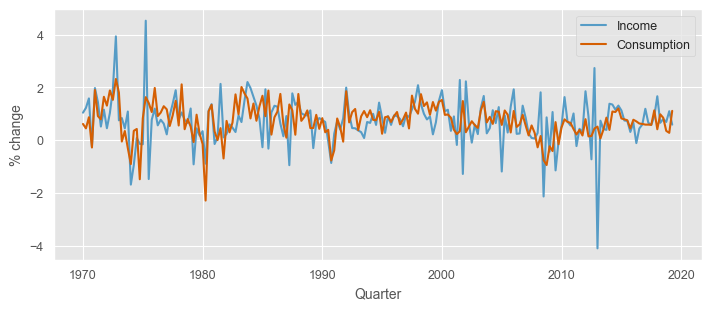

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

us_change = pd.read_csv("../data/fpp3/us_change.csv")

us_change["ds"] = pd.PeriodIndex(
    us_change["Quarter"].str.replace(" ", "", regex=False),
    freq="Q"
).to_timestamp()

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(us_change["ds"], us_change["Income"], label="Income")
ax.plot(us_change["ds"], us_change["Consumption"], label="Consumption")

ax.set(xlabel="Quarter", ylabel="% change")
ax.legend()

plt.show()

In [4]:
us_change

,Quarter,Consumption,Income,Production,Savings,Unemployment,ds
0,1970 Q1,0.619,1.045,-2.452,5.299,0.9,1970-01-01
1,1970 Q2,0.452,1.226,-0.551,7.790,0.5,1970-04-01
2,1970 Q3,0.873,1.585,-0.359,7.404,0.5,1970-07-01
3,1970 Q4,-0.272,-0.240,-2.186,1.170,0.7,1970-10-01
4,1971 Q1,1.901,1.976,1.910,3.536,-0.1,1971-01-01
...,...,...,...,...,...,...,...
193,2018 Q2,0.983,0.662,1.117,-2.724,0.0,2018-04-01
194,2018 Q3,0.853,0.806,1.257,-0.086,-0.3,2018-07-01
195,2018 Q4,0.357,0.695,0.948,5.031,0.2,2018-10-01
196,2019 Q1,0.283,1.101,-0.488,9.760,-0.1,2019-01-01


In [5]:
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

us_change = us_change.assign(
    y=us_change["Consumption"],
    unique_id="US"
)


mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(us_change[["ds", "y", "unique_id", "Income"]],
  fitted=True, static_features=[])

MLForecast(models=[LinearRegression], freq=QS-OCT, lag_features=[], date_features=[], num_threads=1)

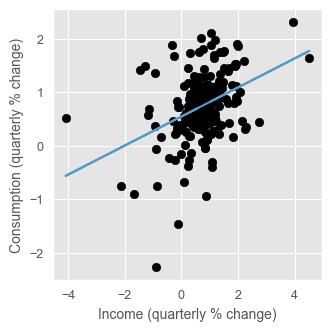

In [6]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
ax.scatter(us_change["Income"], us_change["y"], color="k")
ax.plot(us_change["Income"],
  mf.forecast_fitted_values()["LinearRegression"])
ax.set(xlabel="Income (quarterly % change)",
  ylabel="Consumption (quarterly % change)")
plt.show()

In [7]:
def print_regression_summary_from_model(model):
    X = model._X.values.astype(float)
    y = model._y
    resid = model._residuals
    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    dof = n - p - 1

    percentiles = [0, 25, 50, 75, 100]
    labels = ["Min", "1Q", "Median", "3Q", "Max"]
    percentiles_resid = np.percentile(resid, percentiles)
    resid_summary = pd.DataFrame({
        label: [percentile]
        for label, percentile in zip(labels, percentiles_resid)
    }, index=[""])

    coef = np.insert(model.coef_, 0, model.intercept_)
    rss = np.sum(resid ** 2)
    mse = rss / dof
    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)
    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

    names = ["(Intercept)"] + model._var_names

    stars_lookup = ["***", "**", "*", "."]
    stars_conds = [
        p_values < 0.001,
        p_values < 0.01,
        p_values < 0.05,
        p_values < 0.1
    ]
    stars = np.select(stars_conds, stars_lookup, default="")

    coef_summary = pd.DataFrame({
        "Estimate": coef,
        "Std. Error": se_beta,
        "t value": t_stats,
        "Pr(>|t|)": p_values,
        "": stars
    }, index=names)

    r_squared = model.score(X, y)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / dof
    f_stat = (r_squared / p) / ((1 - r_squared) / dof)
    f_pval = 1 - stats.f.cdf(f_stat, p, dof)

    print(f"Residuals:\n{resid_summary}\n\nCoefficients:\n{coef_summary}")
    print("---")
    signif_code_str = "0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1"
    print(f"Signif. codes: {signif_code_str}\n")
    print(
        f"Residual standard error: {np.sqrt(mse):.3f}",
        f"on {dof} degrees of freedom",
        f"\nMultiple R-squared: {r_squared:.3f},   ",
        f"Adjusted R-squared: {adj_r_squared:.3f}",
        f"\nF-statistic: {f_stat:.1f} on {p}",
        f"and {dof} DF, p-value: {f_pval:.3g}"
    )

In [8]:
reg_df = us_change[["ds", "y", "unique_id", "Income"]]

mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(reg_df, fitted=True, static_features=[])

model = mf.models_["LinearRegression"]

X = reg_df.drop(columns=["unique_id", "ds", "y"])

model._X = X
model._y = reg_df["y"].values
model._residuals = model._y - model.predict(X)
model._var_names = X.columns.tolist()

print_regression_summary_from_model(model)

Residuals:
    Min     1Q  Median     3Q    Max
 -2.582 -0.278   0.019  0.323  1.422

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)     0.545       0.054   10.079  0.000e+00  ***
Income          0.272       0.047    5.817  2.402e-08  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.591 on 196 degrees of freedom 
Multiple R-squared: 0.147,    Adjusted R-squared: 0.143 
F-statistic: 33.8 on 1 and 196 DF, p-value: 2.4e-08


In [9]:
# print_regression_summary(model, X, y)

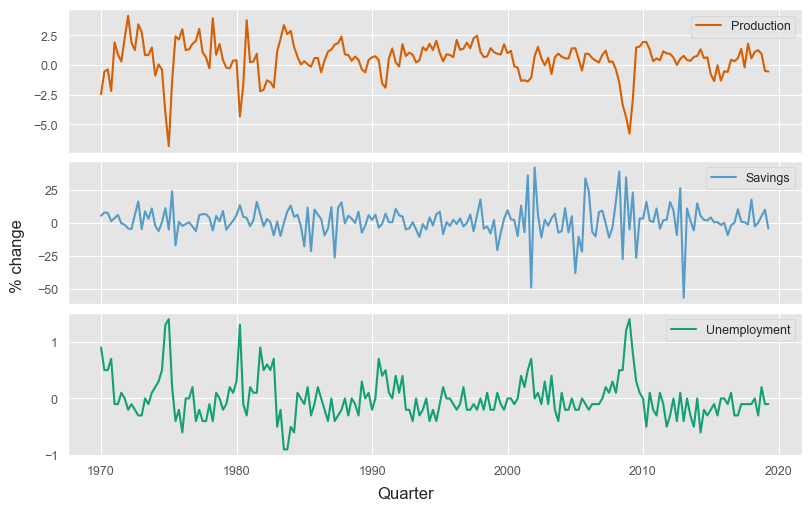

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True)
sns.lineplot(data=us_change, x="ds", y="Production", ax=axes[0],
    color="#D55F03", label="Production")
sns.lineplot(data=us_change, x="ds", y="Savings", ax=axes[1],
    color="#569CC6", label="Savings")
sns.lineplot(data=us_change, x="ds", y="Unemployment", ax=axes[2],
    color="#13A076", label="Unemployment")
for ax in axes:
    ax.set(xlabel="", ylabel="")
fig.supxlabel("Quarter")
fig.supylabel("% change")
plt.show()

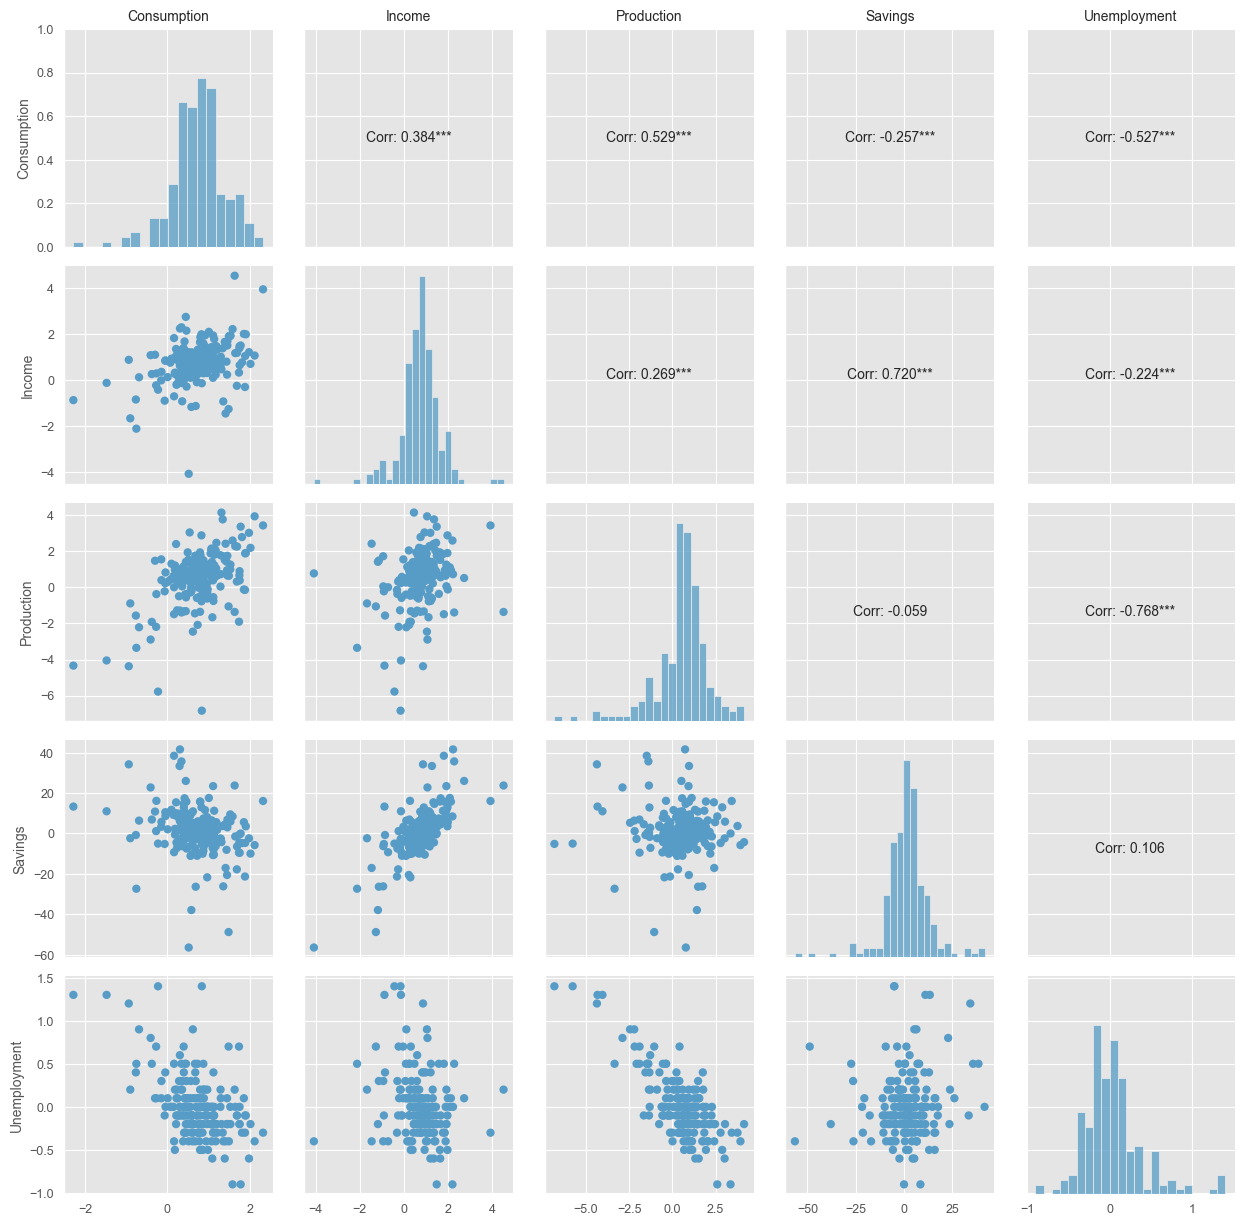

In [11]:
columns = ["y", "Income", "Production", "Savings", "Unemployment"]
df = us_change[columns].rename(columns={'y': 'Consumption'})

def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"Corr: {r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5), xycoords="axes fraction",
        ha="center", va="center")

g = sns.PairGrid(df)
g.map_diag(sns.histplot)
g.map_upper(corrfunc)
g.map_lower(sns.scatterplot, edgecolor="none")
g.add_legend()
# Move x-axis labels to the top
g.set(xlabel="")
for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size='medium')
plt.show()

# 7.2 Least squares estimation


In [12]:
reg_df = us_change[[
    "unique_id", "ds", "y",
    "Income", "Production", "Savings", "Unemployment"
]].dropna()

mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(reg_df, fitted=True, static_features=[])

model = mf.models_["LinearRegression"]

X = reg_df.drop(columns=["unique_id", "ds", "y"])

model._X = X
model._y = reg_df["y"].values
model._residuals = model._y - model.predict(X)
model._var_names = X.columns.tolist()

print_regression_summary_from_model(model)

Residuals:
    Min     1Q  Median     3Q    Max
 -0.906 -0.158  -0.036  0.136  1.155

Coefficients:
              Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)      0.253       0.034    7.343  5.713e-12  ***
Income           0.741       0.040   18.461  0.000e+00  ***
Production       0.047       0.023    2.038  4.287e-02    *
Savings         -0.053       0.003  -18.088  0.000e+00  ***
Unemployment    -0.175       0.096   -1.829  6.895e-02    .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.310 on 193 degrees of freedom 
Multiple R-squared: 0.768,    Adjusted R-squared: 0.763 
F-statistic: 160.0 on 4 and 193 DF, p-value: 1.11e-16


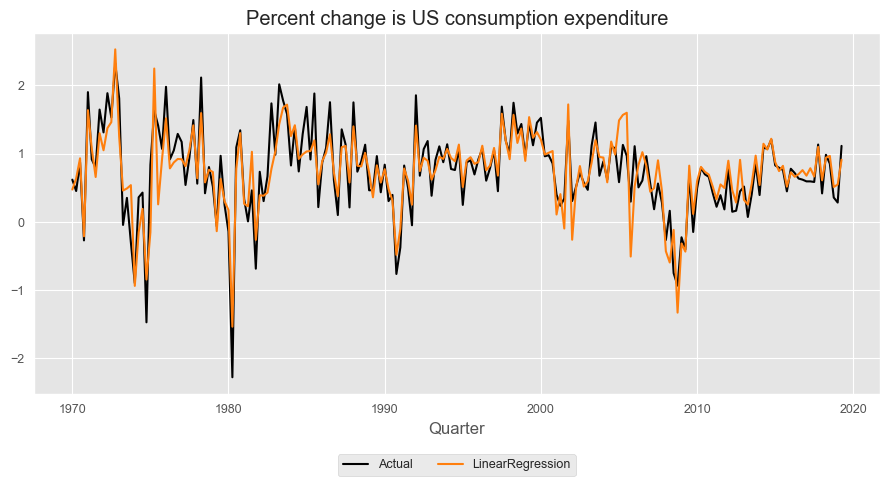

In [13]:
df = mf.forecast_fitted_values().drop(columns="y")

uid = df["unique_id"].iloc[0]

actual_df = us_change.loc[lambda x: x["unique_id"] == uid]
df = df.loc[lambda x: x["unique_id"] == uid]

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)

plt.plot(actual_df["ds"], actual_df["y"], color="black", label="Actual")
plt.plot(df["ds"], df["LinearRegression"], color="tab:orange", label="LinearRegression")

plt.xlabel("Quarter")
plt.ylabel("")
plt.title("Percent change is US consumption expenditure")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

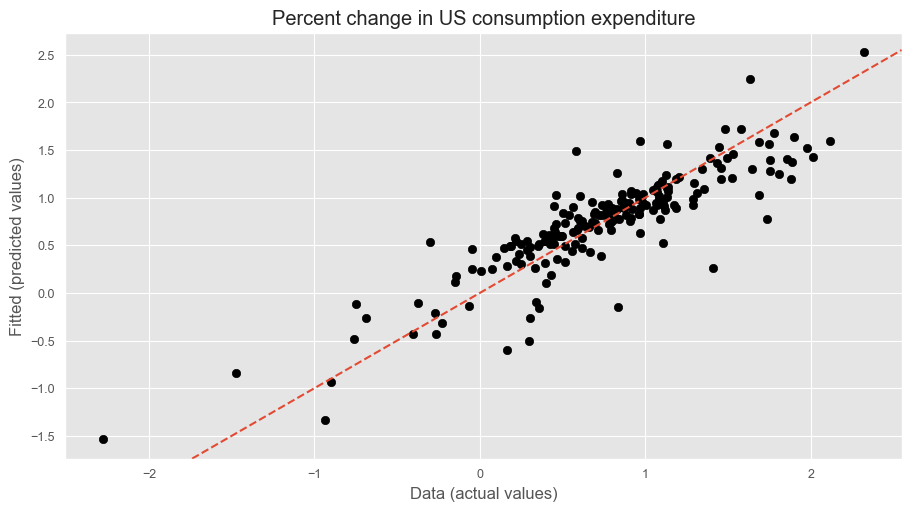

In [14]:
fig, ax = plt.subplots()
insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
ax.scatter(us_change["y"], insample_forecasts, color="k")
ax.axline((0, 0), (1, 1), linestyle="--")
ax.set(
    title="Percent change in US consumption expenditure",
    xlabel="Data (actual values)",
    ylabel="Fitted (predicted values)")
plt.show()

# 7.3 Evaluating the regression model

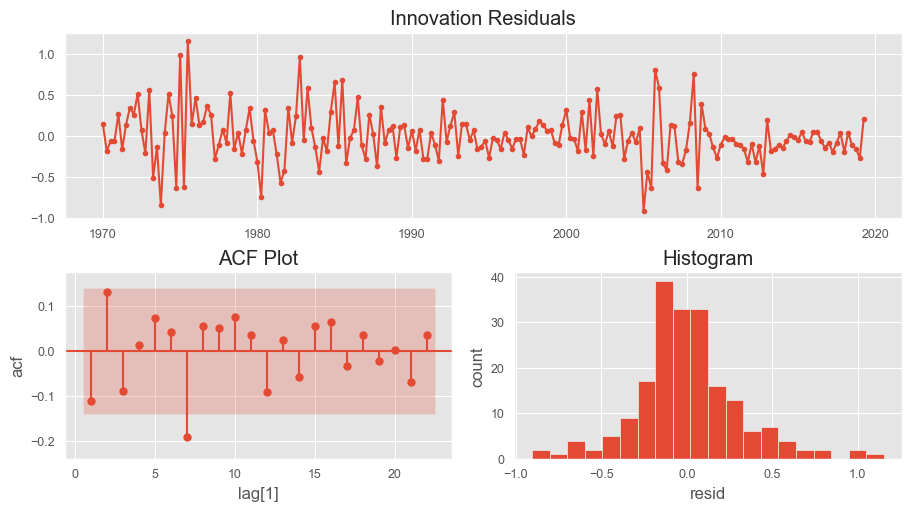

In [15]:
plot_diagnostics(forecaster=mf, n_lags=22)

In [16]:
residuals = mf.models_["LinearRegression"]._residuals
acorr_ljungbox(residuals, lags=[10])

,lb_stat,lb_pvalue
10,18.865,0.042


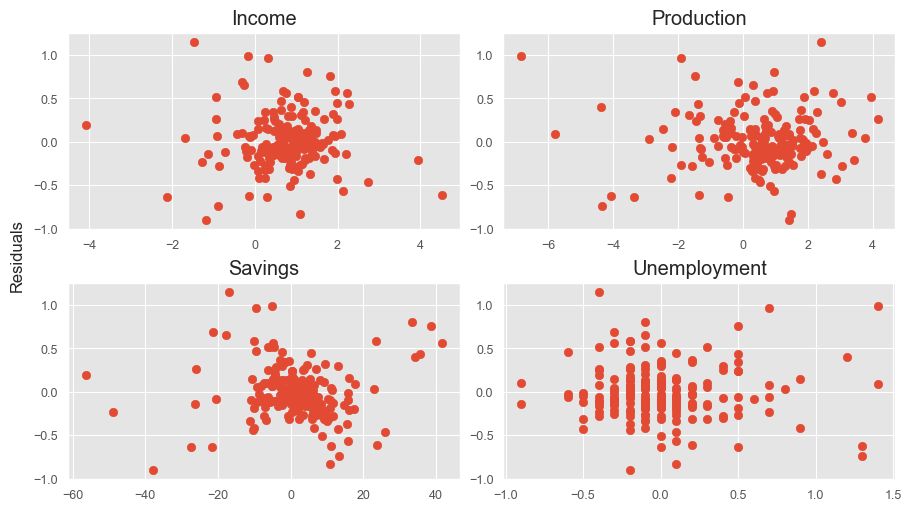

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=2)
columns = ["Income", "Production", "Savings", "Unemployment"]
for ax, column in zip(axes.ravel(), columns):
    ax.scatter(us_change[column], residuals)
    ax.set(title=column)
fig.supylabel("Residuals")
plt.show()

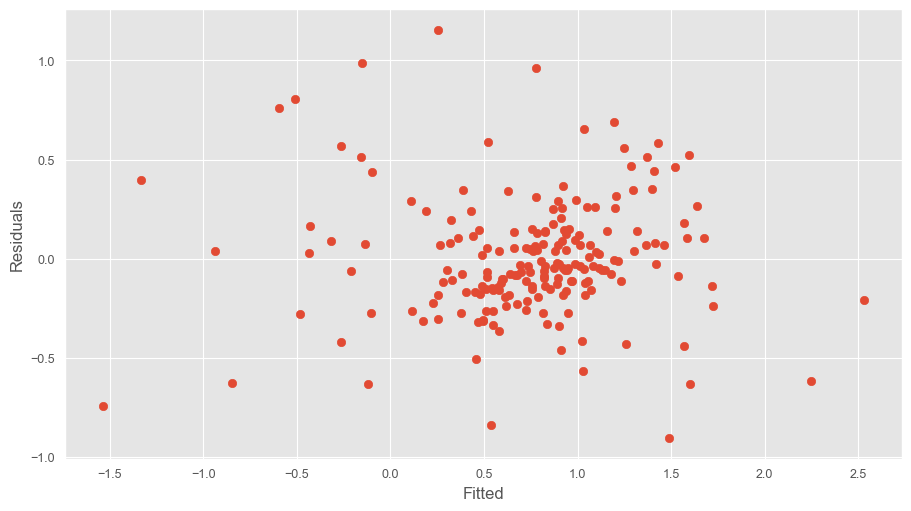

In [18]:
fig, ax = plt.subplots()
ax.scatter(insample_forecasts, residuals)
ax.set(xlabel="Fitted", ylabel="Residuals")
plt.show()

# 7.4 Some useful predictors

In [19]:
aus_production = pd.read_csv("../data/tsibbledata/aus_production.csv")

beer_df = aus_production[["Quarter", "Beer"]].rename(columns={"Beer": "y"})

beer_df["ds"] = (
    pd.PeriodIndex(
        beer_df["Quarter"].str.replace(" ", "", regex=False),
        freq="Q"
    )
    .to_timestamp()
)

beer_df["unique_id"] = "Beer"
beer_df = beer_df[["unique_id", "ds", "y"]]

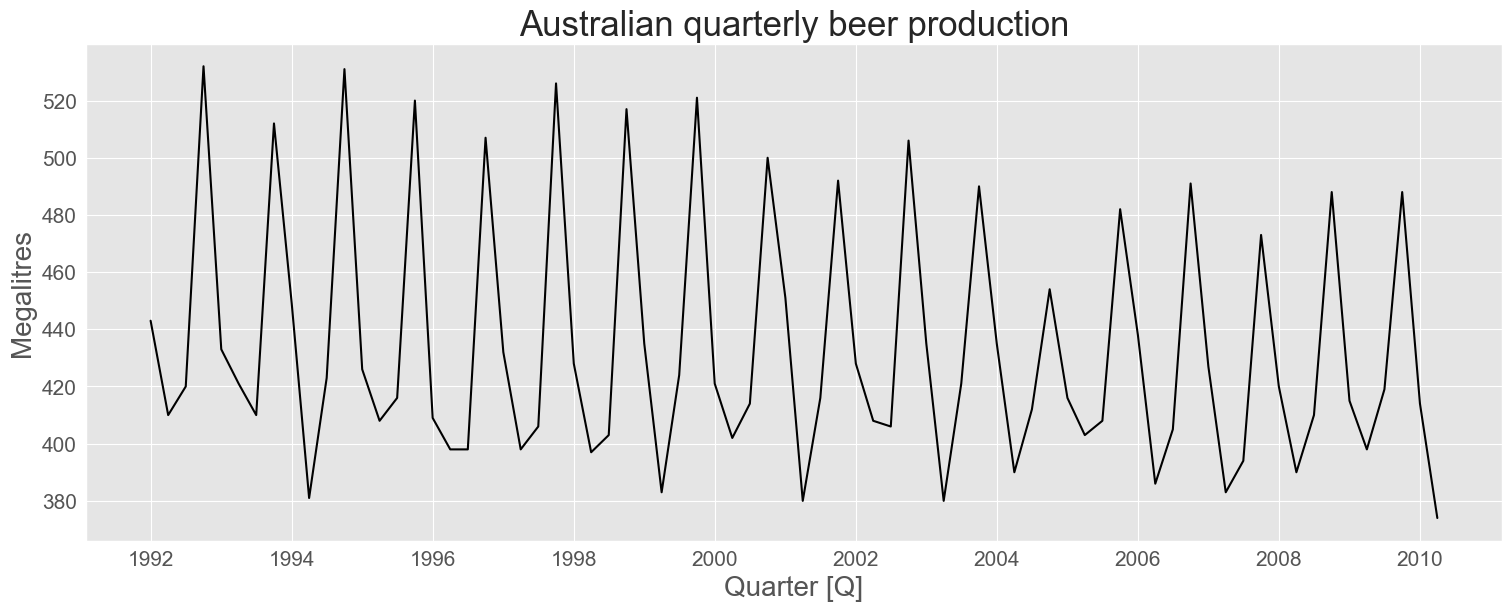

In [20]:
recent_beer = beer_df.loc[lambda x: x["ds"] >= "1992-01-01"]

plot_series(
    recent_beer,
    xlabel="Quarter [Q]",
    ylabel="Megalitres",
    palette="black",
    title="Australian quarterly beer production"
)

In [21]:
from scipy import stats
import numpy as np
import pandas as pd

def print_regression_summary_from_model(mf, df):
    model = mf.models_["LinearRegression"]

    feature_cols = [
        col for col in df.columns
        if col not in ["unique_id", "ds", "y"]
    ]

    X = df[feature_cols].values.astype(float)
    y = df["y"].values.astype(float)

    fitted = model.predict(X)
    resid = y - fitted

    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    dof = n - p - 1

    print("\nResiduals:")
    print(pd.Series(resid).describe(percentiles=[0.25, 0.5, 0.75])[
        ["min", "25%", "50%", "75%", "max"]
    ])

    coef = np.insert(model.coef_, 0, model.intercept_)

    rss = np.sum(resid**2)
    mse = rss / dof

    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)

    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

    coef_names = ["(Intercept)"] + feature_cols

    coef_table = pd.DataFrame({
        "Estimate": coef,
        "Std. Error": se_beta,
        "t value": t_stats,
        "Pr(>|t|)": p_values
    }, index=coef_names)

    print("\nCoefficients:")
    print(coef_table.round(4))

    r2 = model.score(X, y)
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

    print(f"\nResidual standard error: {np.sqrt(mse):.3f} on {dof} degrees of freedom")
    print(f"Multiple R-squared: {r2:.3f}")
    print(f"Adjusted R-squared: {adj_r2:.3f}")

In [22]:
print_regression_summary_from_model(mf, fit_beer)

NameError: name 'fit_beer' is not defined

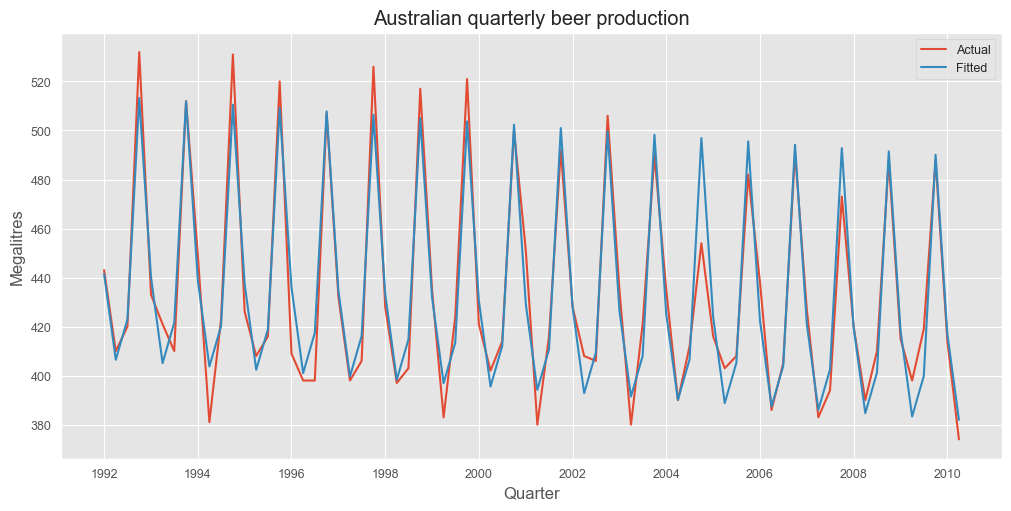

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    fit_beer["ds"],
    fit_beer["y"],
    label="Actual"
)

plt.plot(
    insample["ds"],
    insample["LinearRegression"],
    label="Fitted"
)

plt.title("Australian quarterly beer production")
plt.xlabel("Quarter")
plt.ylabel("Megalitres")
plt.legend()
plt.show()

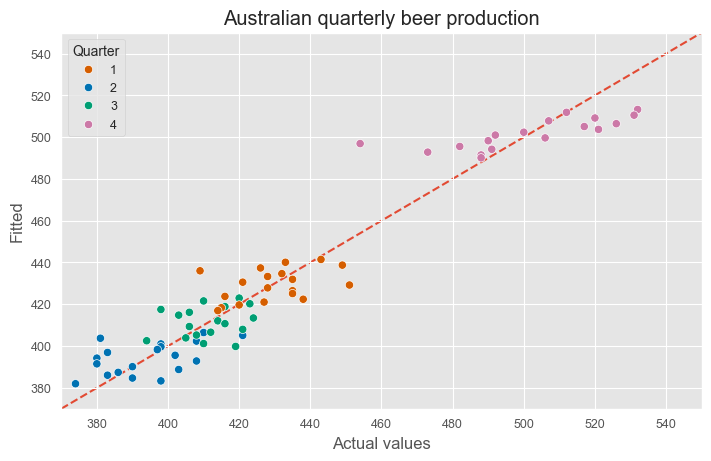

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
df = insample.assign(Quarter=lambda x: x["ds"].dt.quarter)
sns.scatterplot(data=df, x="y", y="LinearRegression",
    hue="Quarter", palette="r_colors")
ax.axline((0, 0), slope=1, linestyle="--", zorder=-1)
ax.set(
    xlim=(370, 550), ylim=(370, 550),
    xlabel="Actual values", ylabel="Fitted",
    title="Australian quarterly beer production",
)
plt.show()

# 7.5 Selecting predictors

In [24]:
from fpppy.models import LinearRegression

us_change = pd.read_csv("../data/fpp3/US_change.csv")
us_change["ds"] = pd.PeriodIndex(
    us_change["Quarter"].str.replace(" ", "", regex=False),
    freq="Q",
).to_timestamp()
us_change = us_change.assign(
    y=us_change["Consumption"],
    unique_id="US",
).drop(columns=["Quarter", "Consumption"])

mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(us_change, fitted=True, static_features=[])
insample = mf.forecast_fitted_values()
insample_forecasts = insample["LinearRegression"]
insample_y = insample["y"]

T = len(insample)
k = len(mf.models_["LinearRegression"].coef_)
adj_r2 = adj_r2_score(insample_y, insample_forecasts, T, k)
cv = cv_score(mf)
aic = aic_score(insample_y, insample_forecasts, T, k)
aicc = aicc_score(insample_y, insample_forecasts, T, k)
bic = bic_score(insample_y, insample_forecasts, T, k)

pd.Series({
    "Adjusted R^2 score": adj_r2,
    "CV score": cv,
    "AIC score": aic,
    "AICc score": aicc,
    "BIC score": bic,
})

Adjusted R^2 score      0.763
CV score                0.104
AIC score            -456.580
AICc score           -456.140
BIC score            -436.850
dtype: float64

In [25]:
import pandas as pd
from fpppy.models import LinearRegression
from mlforecast import MLForecast

predictors = ["Income", "Production", "Savings", "Unemployment"]

def fit_and_score(subset):
    cols = ["ds", "unique_id", "y"] + list(subset)
    mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
    mf.fit(us_change[cols], fitted=True, static_features=[])
    insample = mf.forecast_fitted_values()

    y = insample["y"]
    fitted = insample["LinearRegression"]
    T = len(insample)
    k = len(subset)

    return {
        "predictors": ", ".join(subset),
        "AdjR2": adj_r2_score(y, fitted, T, k),
        "CV": cv_score(mf),
        "AIC": aic_score(y, fitted, T, k),
        "AICc": aicc_score(y, fitted, T, k),
        "BIC": bic_score(y, fitted, T, k),
    }

current = list(predictors)
history = []

while True:
    score = fit_and_score(current)
    history.append(score)

    # try removing each remaining predictor
    candidates = []
    for p in current:
        candidate = [x for x in current if x != p]
        if not candidate:          # skip intercept-only (MLForecast can't fit it)
            continue
        cand_score = fit_and_score(candidate)
        candidates.append((cand_score["AICc"], p, candidate, cand_score))

    if not candidates:
        break

    best_aicc, removed, next_predictors, _ = min(candidates, key=lambda x: x[0])

    if best_aicc < score["AICc"]:
        print(f"Remove {removed}: AICc {score['AICc']:.3f} -> {best_aicc:.3f}")
        current = next_predictors
    else:
        print("Stop: removing any predictor worsens AICc")
        break

results_df = pd.DataFrame(history)
results_df

Stop: removing any predictor worsens AICc


,predictors,AdjR2,CV,AIC,AICc,BIC
0,"Income, Production, Savings, Unemployment",0.763,0.104,-456.58,-456.14,-436.85


In [27]:
from itertools import combinations
import pandas as pd
from fpppy.models import LinearRegression
from mlforecast import MLForecast

predictors = ["Income", "Production", "Savings", "Unemployment"]
results = []

for r in range(1, len(predictors) + 1):          # skip empty subset
    for subset in combinations(predictors, r):
        cols = ["ds", "unique_id", "y"] + list(subset)

        mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
        mf.fit(us_change[cols], fitted=True, static_features=[])

        insample = mf.forecast_fitted_values()
        y = insample["y"]
        fitted = insample["LinearRegression"]
        T = len(insample)
        k = len(subset)

        results.append({
            "predictors": ", ".join(subset),
            "AdjR2": adj_r2_score(y, fitted, T, k),
            "CV": cv_score(mf),
            "AIC": aic_score(y, fitted, T, k),
            "AICc": aicc_score(y, fitted, T, k),
            "BIC": bic_score(y, fitted, T, k),
        })

results_df = pd.DataFrame(results).sort_values("AICc")
results_df

,predictors,AdjR2,CV,AIC,AICc,BIC
14,"Income, Production, Savings, Unemployment",0.763,0.104,-456.580,-456.140,-436.850
10,"Income, Production, Savings",0.761,0.105,-455.178,-454.865,-438.736
12,"Income, Savings, Unemployment",0.760,0.104,-454.362,-454.050,-437.921
5,"Income, Savings",0.735,0.114,-435.717,-435.510,-422.564
11,"Income, Production, Unemployment",0.366,0.271,-262.274,-261.961,-245.833
13,"Production, Savings, Unemployment",0.349,0.279,-257.138,-256.826,-240.697
6,"Income, Unemployment",0.345,0.276,-256.850,-256.643,-243.697
4,"Income, Production",0.336,0.282,-254.161,-253.954,-241.008
7,"Production, Savings",0.324,0.287,-250.679,-250.472,-237.526
9,"Savings, Unemployment",0.311,0.291,-246.891,-246.684,-233.738


### R (Correlation Coefficient)

R measures the strength and direction of the linear relationship between two variables.

R ranges from -1 to 1.

R = 1 means a perfect positive linear relationship.

R = -1 means a perfect negative linear relationship.

R = 0 means no linear relationship.

The closer |R| is to 1, the stronger the linear relationship.


### R² (Coefficient of Determination)

R² measures how much of the variation in the target variable is explained by the model.

R² ranges from 0 to 1.

R² = 0 means the model explains none of the variation.

R² = 1 means the model explains all of the variation.

An R² of 0.76 means that 76% of the variation in the target is explained by the model.

R² measures goodness of fit, not forecasting accuracy.

Adding predictors usually increases R², even if they are not useful.


### p-value

A p-value measures the evidence that a predictor's coefficient is different from zero.

A small p-value suggests the predictor contributes information beyond the other predictors in the model.

A large p-value suggests there is little evidence that the predictor adds unique information.

A common threshold is p < 0.05 for statistical significance.

Statistical significance does not necessarily imply forecasting usefulness.

A predictor can have a large p-value and still improve forecast accuracy.

### Fourier Series

A Fourier series is a way of representing a repeating pattern using sine and cosine waves.

Fourier terms are often used to model seasonality in time series data.

Instead of creating many seasonal dummy variables, Fourier terms can capture seasonality with only a few variables.

A Fourier series is made up of pairs of sine and cosine terms.

Each pair represents a seasonal pattern with a different frequency.

More Fourier terms allow the model to capture more complex seasonal patterns.

Too many Fourier terms can lead to overfitting.

Fourier terms are especially useful for long seasonal periods such as daily data with yearly seasonality.

Fourier terms do not forecast by themselves; they are used as predictors in another model such as linear regression, ARIMA, or ETS.

The model learns how much weight to assign to each sine and cosine wave.

Fourier terms provide a smooth representation of seasonality.

Seasonal dummy variables and Fourier terms are two different ways of modeling seasonality.

Seasonal dummies assign a separate coefficient to each season.

Fourier terms model seasonality using smooth sine and cosine waves.

Fourier terms are often preferred when the seasonal period is large because they require far fewer predictors than seasonal dummy variables.

# 7.6 Forecasting with regression

In [ ]:
fit_beer = recent_beer.copy()
features = [trend, partial(fourier, season_length=4, k=1)]
fit_beer_with_predictors, future_predictors = pipeline(
    fit_beer, features=features, freq="QS-DEC", h=8)
mf = MLForecast(models=LinearRegression(), freq="QS-DEC")
mf.fit(fit_beer_with_predictors, static_features=[],
    prediction_intervals=PredictionIntervals(n_windows=4, h=8))
forecasts = mf.predict(h=8, X_df=future_predictors, level=[80, 95])

plot_series(
  df=fit_beer, forecasts_df=forecasts, level=[80, 95],
  xlabel="Quarter", ylabel="megalitres",
  title="Forecasts of beer production using regression",
  palette="black_and_blue", rm_legend=False,
  legend_loc="outside lower center"
)

# 7.7 Nonlinear regression